In [1]:
# Install kagglehub if not already installed
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import os

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print(f"Path to dataset files: {dataset_path}")

# List the contents of the downloaded dataset directory
print("Contents of the downloaded dataset:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



                Tomato___Spider_mites Two-spotted_spider_mite/
                    003b7929-a364-4e74-be1c-37c4c0a6ec63___Com.G_SpM_FL 1414.JPG
                    003b7929-a364-4e74-be1c-37c4c0a6ec63___Com.G_SpM_FL 1414_180deg.JPG
                    003b7929-a364-4e74-be1c-37c4c0a6ec63___Com.G_SpM_FL 1414_flipTB.JPG
                    00bc7858-1dca-4bfb-a828-225f03bd72a5___Com.G_SpM_FL 9455_180deg.JPG
                    00bc7858-1dca-4bfb-a828-225f03bd72a5___Com.G_SpM_FL 9455_flipTB.JPG
                    00c8e9a0-1fb8-434b-8981-25511358ddc9___Com.G_SpM_FL 8717.JPG
                    00c8e9a0-1fb8-434b-8981-25511358ddc9___Com.G_SpM_FL 8717_180deg.JPG
                    00c8e9a0-1fb8-434b-8981-25511358ddc9___Com.G_SpM_FL 8717_flipTB.JPG
                    00fa99e8-2605-4d72-be69-98277587d84b___Com.G_SpM_FL 1453.JPG
                    00fa99e8-2605-4d72-be69-98277587d84b___Com.G_SpM_FL 1453_180deg.JPG
                    0100e504-f6bc-464a-a181-38262117f30a___Com.G_SpM_FL 1202.J

In [3]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

def display_random_images(dataset_root_path, num_images=5):
    """
    Displays a specified number of random images from the dataset.

    Args:
        dataset_root_path (str): The root path of the dataset (e.g., the 'PlantVillage' folder).
        num_images (int): The number of random images to display.
    """
    all_image_paths = []
    for root, _, files in os.walk(dataset_root_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print("No images found in the specified dataset path.")
        return

    selected_images = random.sample(all_image_paths, min(num_images, len(all_image_paths)))

    plt.figure(figsize=(15, 5 * len(selected_images)))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            # Extract label from the parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            if label == 'train' or label == 'val' or label == 'test': # Handle cases where direct parent is train/val/test
                label = os.path.basename(os.path.dirname(os.path.dirname(img_path)))

            plt.subplot(len(selected_images), 3, i*3 + 1) # Adjust subplot layout for better display
            plt.imshow(img)
            plt.title(f"Label: {label}\nFile: {os.path.basename(img_path)}", fontsize=8)
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")

    plt.tight_layout()
    plt.show()


Now, let's try displaying a few random images from the training subset of the dataset. The `dataset_path` variable points to the root of the downloaded dataset.

Attempting to access: /home/madhavrimal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Path '/home/madhavrimal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train' exists. Proceeding to display images.


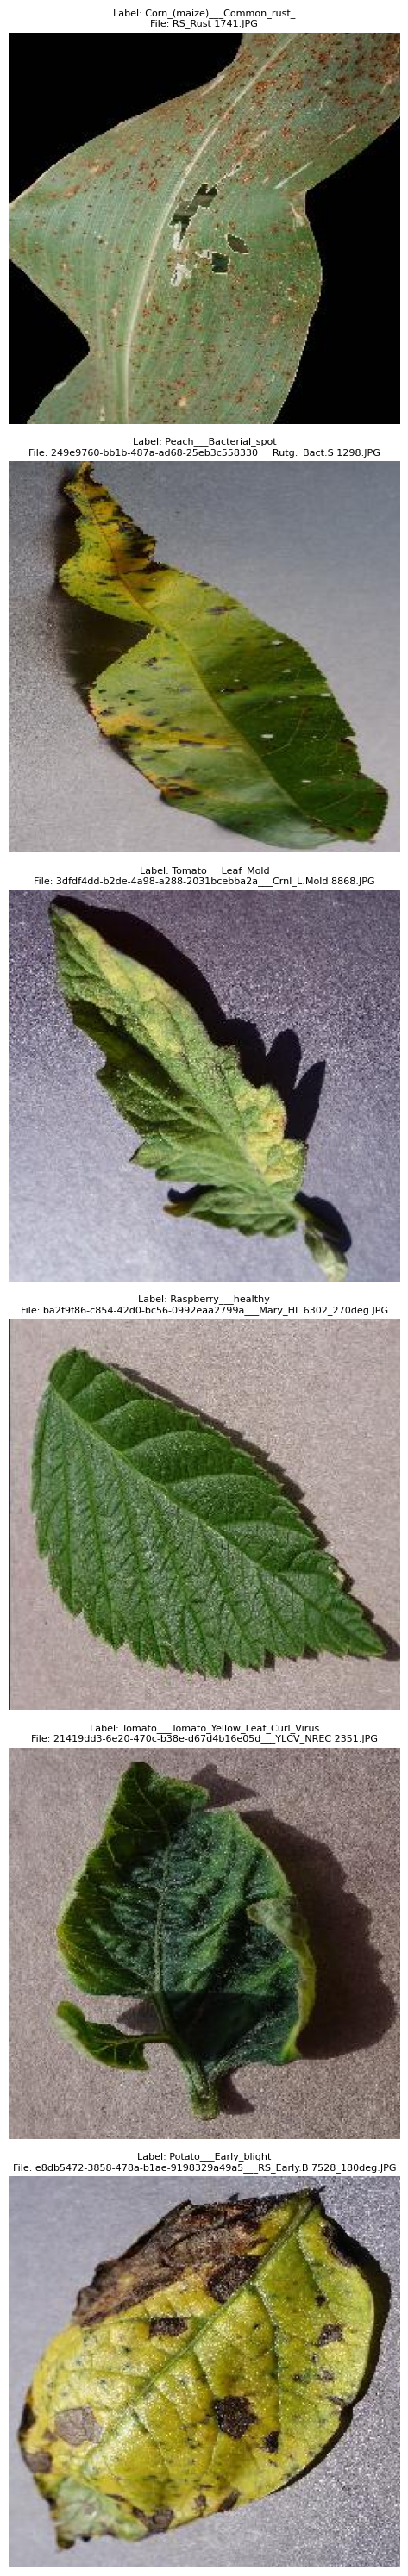

In [4]:
import os # Ensure os is imported for path operations

# The dataset_path is '/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2'
# The 'train' folder is nested inside 'New Plant Diseases Dataset(Augmented)' which is nested again.
train_data_root_path = os.path.join(dataset_path, 'New Plant Diseases Dataset(Augmented)', 'New Plant Diseases Dataset(Augmented)')
train_data_path = os.path.join(train_data_root_path, 'train')

print(f"Attempting to access: {train_data_path}")

if os.path.exists(train_data_path):
    print(f"Path '{train_data_path}' exists. Proceeding to display images.")
    display_random_images(train_data_path, num_images=6)
else:
    print(f"Error: Path '{train_data_path}' does not exist. Please check the dataset structure.")
    # Further debugging for the user if the path still doesn't exist
    print(f"Contents of dataset_path ({dataset_path}): {os.listdir(dataset_path) if os.path.exists(dataset_path) else 'Path does not exist.'}")
    parent_dir_one = os.path.join(dataset_path, 'New Plant Diseases Dataset(Augmented)')
    if os.path.exists(parent_dir_one):
        print(f"Contents of first 'New Plant Diseases Dataset(Augmented)' folder: {os.listdir(parent_dir_one)}")
        parent_dir_two = os.path.join(parent_dir_one, 'New Plant Diseases Dataset(Augmented)')
        if os.path.exists(parent_dir_two):
            print(f"Contents of second 'New Plant Diseases Dataset(Augmented)' folder: {os.listdir(parent_dir_two)}")
            # Check for 'train' directory directly here
            train_check = os.path.join(parent_dir_two, 'train')
            if os.path.exists(train_check):
                print(f"'train' directory found at: {train_check}")

## Data Exploration and Feature Extraction

Let's begin by understanding the dataset structure and distribution of classes.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths for train, validation, and test datasets
# Re-using train_data_root_path from the previous cell for consistency
valid_data_path = os.path.join(train_data_root_path, 'valid')
test_data_path = os.path.join(dataset_path, 'test', 'test') # The top-level 'test' folder contains another 'test' folder

print(f"Train Data Path: {train_data_path}")
print(f"Validation Data Path: {valid_data_path}")
print(f"Test Data Path: {test_data_path}")


Train Data Path: /home/madhavrimal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation Data Path: /home/madhavrimal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Test Data Path: /home/madhavrimal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test


In [6]:
def count_images_and_classes(data_path):
    """
    Counts the number of images and classes in a given dataset path.
    Assumes the structure: data_path/class_name/image.jpg
    """
    class_counts = {}
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = num_images
    return class_counts

# Get class distribution for the training set
train_class_counts = count_images_and_classes(train_data_path)

# Convert to DataFrame for easier plotting and analysis
train_df = pd.DataFrame(train_class_counts.items(), columns=['Class', 'Count'])

display(train_df.head())


,Class,Count
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


### Training Data Class Distribution

/tmp/ipykernel_16761/2694254974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=train_df, palette='viridis')


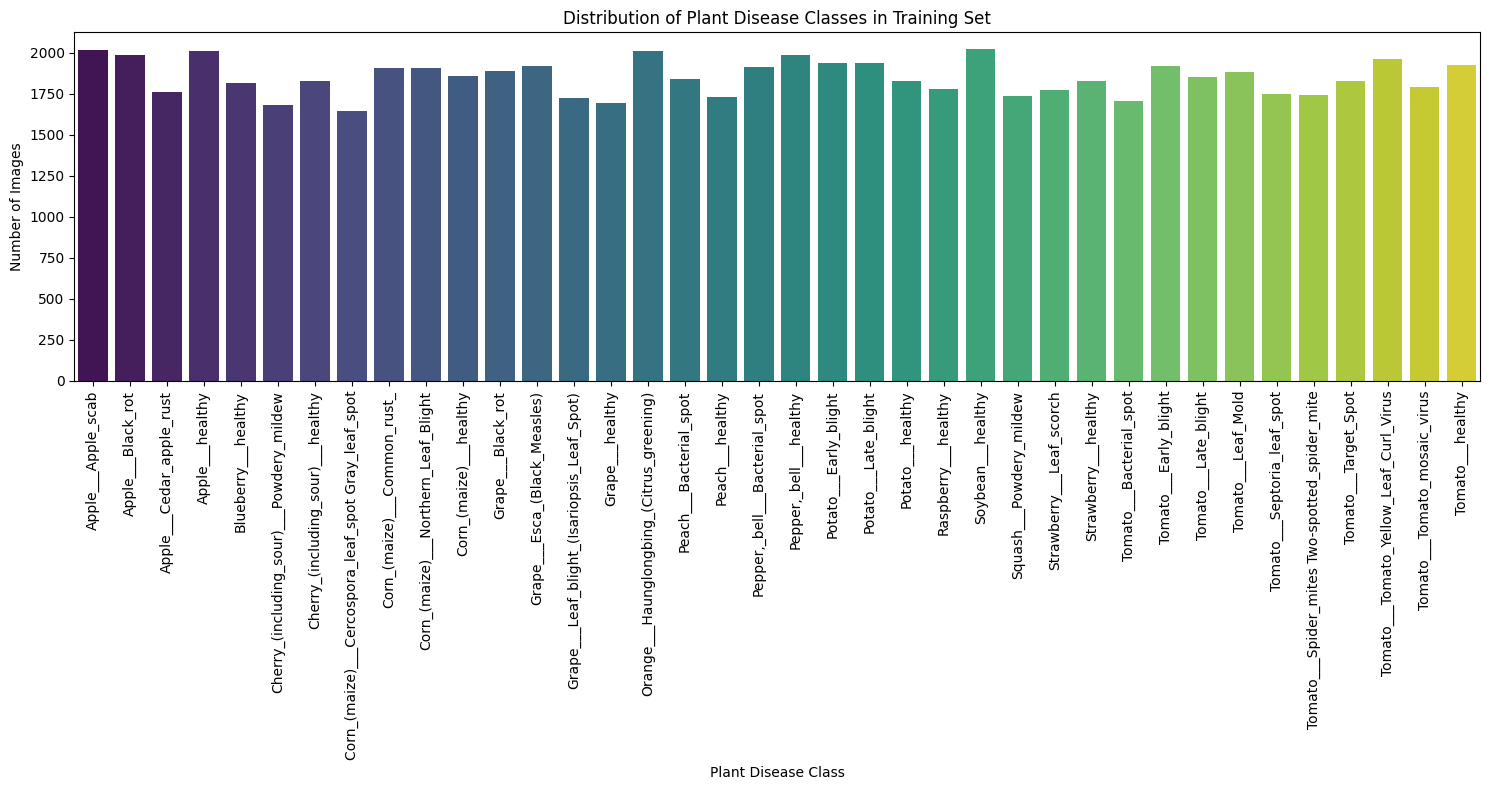

In [7]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=train_df, palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Plant Disease Classes in Training Set')
plt.xlabel('Plant Disease Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()


### Validation Data Class Distribution

,Class,Count
0,Apple___Apple_scab,504
1,Apple___Black_rot,497
2,Apple___Cedar_apple_rust,440
3,Apple___healthy,502
4,Blueberry___healthy,454


/tmp/ipykernel_16761/3150188479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=valid_df, palette='viridis')


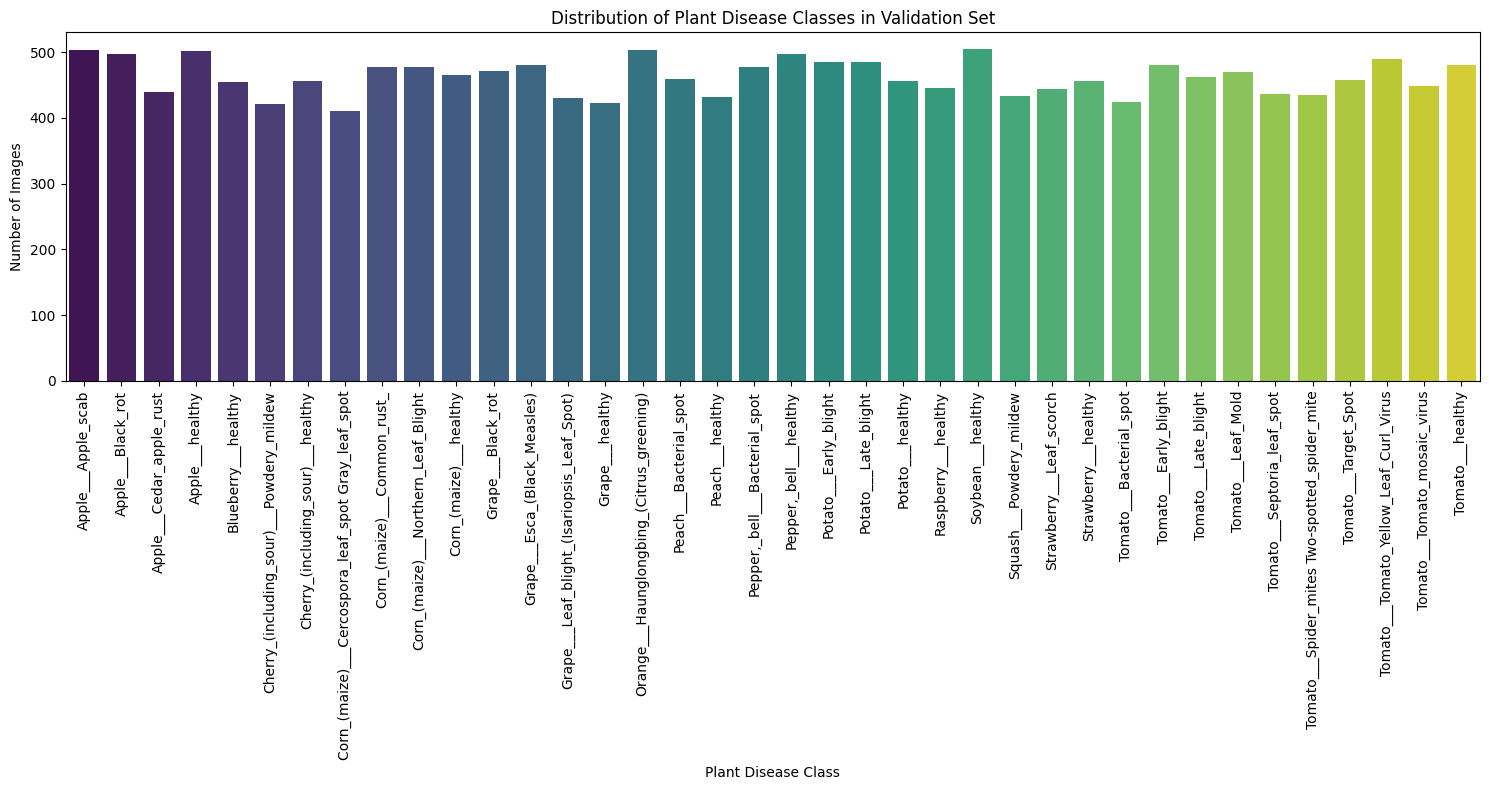

In [8]:
# Get class distribution for the validation set
valid_class_counts = count_images_and_classes(valid_data_path)
valid_df = pd.DataFrame(valid_class_counts.items(), columns=['Class', 'Count'])

display(valid_df.head())

plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=valid_df, palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Plant Disease Classes in Validation Set')
plt.xlabel('Plant Disease Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

### Test Data Class Distribution

Total number of test images found: 33


,Class,Count
0,Total Test Images (Unlabeled),33


/tmp/ipykernel_16761/1196997193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=test_df, palette='viridis')


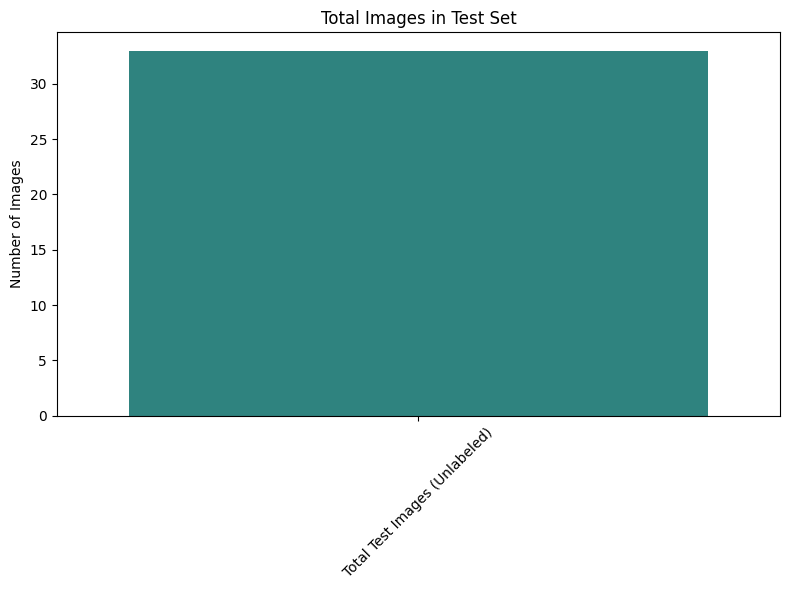

In [9]:
# Get class distribution for the test set
# The test set images are typically not in class-labeled subdirectories
# Instead, they are directly in the test_data_path
test_image_files = [f for f in os.listdir(test_data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
total_test_images = len(test_image_files)

# Create a DataFrame to represent the total count
test_df = pd.DataFrame([{'Class': 'Total Test Images (Unlabeled)', 'Count': total_test_images}])

print(f"Total number of test images found: {total_test_images}")
display(test_df) # Display the DataFrame with total count

# Plotting (will show a single bar for total test images)
plt.figure(figsize=(8, 6)) # Adjust figure size for a single bar
sns.barplot(x='Class', y='Count', data=test_df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Total Images in Test Set')
plt.xlabel('') # No specific classes to label
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## Data Preparation for Model Training

To prepare the images for training a deep learning model, we'll use `ImageDataGenerator` from TensorFlow/Keras. This will handle:

*   **Rescaling:** Normalizing pixel values to a [0, 1] range.
*   **Image Resizing:** Resizing all images to a consistent size (e.g., 224x224 pixels).
*   **Batching:** Grouping images into batches for efficient model training.
*   **Data Augmentation (for training set):** Applying transformations like rotations, shifts, and flips to the training images to increase the diversity of the training data and improve model generalization.


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=40, # Randomly rotate images by up to 40 degrees
    width_shift_range=0.2, # Randomly shift images horizontally
    height_shift_range=0.2, # Randomly shift images vertically
    shear_range=0.2, # Apply shearing transformations
    zoom_range=0.2, # Apply random zoom
    horizontal_flip=True, # Randomly flip images horizontally
    fill_mode='nearest' # Fill new pixels created by transformations
)

# Create ImageDataGenerator for validation and test sets (only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators initialized.")

I0000 00:00:1779761509.295950   16761 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779761509.517296   16761 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779761510.709042   16761 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


ImageDataGenerators initialized.


Now, let's create the actual data generators using `flow_from_directory`. These generators will load images from our defined paths, apply the preprocessing steps, and serve them in batches to the model.

In [11]:
# Create training data generator
train_generator = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # For multi-class classification
)

# Create validation data generator
validation_generator = validation_datagen.flow_from_directory(
    valid_data_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create test data generator
# For the test set, we need to handle that images are not in subdirectories by class.
# We set class_mode=None and shuffle=False to get predictions in order.
# However, to maintain consistency with `flow_from_directory` and avoid issues with target_size, we'll assume
# the user intends to classify these directly. If labels are needed later, a custom generator might be required.
# For now, let's adapt `flow_from_directory` by pointing it to the folder containing the images directly.
# This will treat each image as its own 'class' effectively for this step if it expects subfolders, or more ideally
# if the test path only contains images, it will generate them without class labels.

# A more robust approach for test data without subfolders:
# test_generator = test_datagen.flow_from_dataframe(
#     dataframe=pd.DataFrame({'filename': test_image_files}), # Assuming test_image_files is a list of filenames
#     directory=test_data_path,
#     x_col='filename',
#     y_col=None,
#     target_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE,
#     class_mode=None,
#     shuffle=False
# )

# Given `test_data_path` points directly to the images, we can use `flow_from_directory` but with a caveat:
# It expects subdirectories. Since the test data doesn't have class subdirectories, we will use `flow_from_directory`
# on the parent folder of `test_data_path` and specify `classes=[os.path.basename(test_data_path)]`.
# This effectively tells it to treat all images within `test_data_path` as one 'class'.

# Determine the parent directory of test_data_path
test_parent_path = os.path.dirname(test_data_path)
test_dir_name = os.path.basename(test_data_path)

# Create test data generator for unlabeled test images
test_generator = test_datagen.flow_from_directory(
    test_parent_path, # Point to the parent directory
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode=None, # No class labels needed for prediction
    shuffle=False, # Keep file order for potential later mapping
    classes=[test_dir_name] # Specify the 'class' as the folder name containing the images
)

print("Data generators created.")
print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Number of classes: {train_generator.num_classes}")
print(f"Class labels: {train_generator.class_indices}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 33 images belonging to 1 classes.
Data generators created.
Number of training samples: 70295
Number of validation samples: 17572
Number of test samples: 33
Number of classes: 38
Class labels: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Pot

## Define and Compile the CNN Model

Now, let's define the architecture of our Convolutional Neural Network (CNN). We'll start with a relatively simple sequential model that includes convolutional layers for feature extraction and dense layers for classification. We'll use `tf.keras.applications.MobileNetV2` as a base for transfer learning to leverage pre-trained weights on a large dataset, which usually leads to better performance on image tasks with limited data. This will be adapted for our specific number of classes.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

# Get the number of classes from the training generator
num_classes = train_generator.num_classes

# Load the MobileNetV2 model with pre-trained weights (ImageNet) excluding the top classification layer
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')

# Freeze the base model layers so they are not updated during initial training
base_model.trainable = False

# Create a new model on top of the pre-trained base
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Reduces spatial dimensions to a single vector
    Dense(128, activation='relu'), # A dense layer for further feature processing
    Dropout(0.5), # Dropout for regularization
    Dense(num_classes, activation='softmax') # Output layer for classification
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a small learning rate for fine-tuning/transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model defined and compiled using MobileNetV2 for transfer learning.")
model.summary()

I0000 00:00:1779761514.759169   16761 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


CNN model defined and compiled using MobileNetV2 for transfer learning.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the Model

Now we will train the defined CNN model using the `train_generator` and `validation_generator`. We'll also use `EarlyStopping` to stop training when the validation loss stops improving, and `ModelCheckpoint` to save the best model weights during training.

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint = ModelCheckpoint(
    'best_plant_disease_model.keras', # Filepath to save the model
    monitor='val_loss', # Monitor validation loss
    save_best_only=True, # Save only the best model
    mode='min', # The 'best' model has the minimum validation loss
    verbose=1 # Log when model is saved
)

epochs = 20 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint]
)
# BUG : Requires batch training for the model
print("Model training complete.")

Epoch 1/20


I0000 00:00:1779761516.458471   16761 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779761518.352251   16914 service.cc:153] XLA service 0x7f43c0034bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779761518.352269   16914 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779761518.404644   16914 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779761518.898075   16914 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779761518.939153   16914 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8090__.123
I0000 00:00:1779761521.095961   16914 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. May

   1/2197 ━━━━━━━━━━━━━━━━━━━━ 7:02:28 12s/step - accuracy: 0.0312 - loss: 4.2868

I0000 00:00:1779761527.952588   16914 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 173/2197 ━━━━━━━━━━━━━━━━━━━━ 6:08 182ms/step - accuracy: 0.0579 - loss: 3.7520

I0000 00:00:1779761559.943430   16906 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8090__.123
I0000 00:00:1779761564.883167   16906 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.3216 - loss: 2.5470

I0000 00:00:1779761957.555607   16908 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_loss improved from None to 0.73447, saving model to best_plant_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 467s 208ms/step - accuracy: 0.4918 - loss: 1.8411 - val_accuracy: 0.8111 - val_loss: 0.7345
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7060 - loss: 0.9872
Epoch 2: val_loss improved from 0.73447 to 0.49258, saving model to best_plant_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 369s 168ms/step - accuracy: 0.7286 - loss: 0.9061 - val_accuracy: 0.8625 - val_loss: 0.4926
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7753 - loss: 0.7372
Epoch 3: val_loss improved from 0.49258 to 0.39924, saving model to best_plant_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 388s 177ms/step - accuracy: 0.7862 - loss: 0.7001 - val_accuracy: 0.8833 - val_loss: 0.3992
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8109 - loss: 0.6206
Epoch 4: val_loss improved from 0.39924 to 0.35779, saving model t

KeyboardInterrupt: 

## Recommended Reading and Documentation

To better understand the current and upcoming steps in building and training this plant disease detection system, here are some key topics and resources:

### 1. Convolutional Neural Networks (CNNs)

*   **Concept:** CNNs are the backbone of most modern image classification models. They are designed to automatically learn spatial hierarchies of features from image data.
*   **Recommended Reading:**
    *   [**Deep Learning Book - Chapter 9: Convolutional Networks**](https://www.deeplearningbook.org/contents/convnets.html): A comprehensive theoretical overview.
    *   [**Stanford CS231n: Convolutional Neural Networks for Visual Recognition**](https://cs231n.github.io/convolutional-networks/): Excellent course notes with intuitive explanations and visualizations.

### 2. Transfer Learning

*   **Concept:** Transfer learning involves using a pre-trained model (like MobileNetV2 in our case) that was trained on a very large dataset (e.g., ImageNet) and adapting it to a new, but similar, task. This is highly effective when you have limited data for your specific problem.
*   **Recommended Reading:**
    *   [**Keras Guide: Transfer learning & fine-tuning**](https://keras.io/guides/transfer_learning/): A practical guide on how to implement transfer learning in Keras.
    *   [**Towards Data Science: A Step-by-Step Guide to Transfer Learning for Computer Vision**](https://towardsdatascience.com/a-step-by-step-guide-to-transfer-learning-for-computer-vision-with-code-5f110757a31b): An article with code examples.

### 3. Image Data Augmentation

*   **Concept:** Data augmentation is a technique to increase the diversity of your training data by applying random transformations (like rotation, shifting, zooming, flipping) to your images. This helps prevent overfitting and improves the model's generalization.
*   **Recommended Reading:**
    *   [**Keras Documentation: ImageDataGenerator**](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator): Official documentation for the tool we are using.
    *   [**Analytics Vidhya: Image Augmentation for Deep Learning using Keras**](https://www.analyticsvidhya.com/blog/2019/07/build-image-classification-game-deep-learning-keras/): A blog post explaining augmentation techniques.

### 4. Model Evaluation Metrics

*   **Concept:** After training, we need to evaluate how well our model performs. Key metrics include accuracy, precision, recall, F1-score, and confusion matrices.
*   **Recommended Reading:**
    *   [**Scikit-learn User Guide: Classification metrics**](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics): Overview of various classification metrics.
    *   [**Confusion Matrix Explained**](https://www.v7labs.com/blog/confusion-matrix): An easy-to-understand explanation of confusion matrices.

These resources should provide a solid foundation for understanding each step of the process. Feel free to ask if you have specific questions about any of these topics!

In [ ]:
# This cell is just a trigger to execute the previous modified cell.
# The actual logic is in cell 7ca61d35.
print("Executing cell 7ca61d35 to analyze test data...")